# NB9 — Automated Diagnostics: Confidence Stratification, Image-Quality, Overlay-Artifact Attention

**GastroNet project — Part 1 follow-up (post NB6/NB6b/NB7/NB8).**

NB6/NB6b already established: 4 architectures are statistically tied on accuracy,
and only **19 of 400** test images produce any disagreement across the 4 models.
This notebook runs **fully automated, quantitative** diagnostics on exactly those
19 images — no manual pathology judgment required, since none of us reviewing
this are clinicians. Everything here is either a pixel-statistic, a model output
(confidence/entropy), or an attention-mass measurement.

Sections:
1. Setup + verbatim model/dataset code (copied from NB7, unchanged)
2. Select the 19 disagreement images (recomputed from `results.json`, self-contained)
3. Confidence stratification (Section 11 of the brief, automated)
4. Automated image-quality diagnostics: blur / brightness / contrast / glare (Section 9, automated)
5. Overlay-artifact attention quantification (Section 6/13-style, automated corner-mass heuristic)
6. Cross-model error-overlap summary (Section 15, automated)
7. Auto-generated hypothesis report (Section 36 format)
8. Save outputs + contact sheet

**Important framing**: automated flags below (e.g. "high glare", "corner-attention above baseline")
are *candidates for a human to glance at*, not conclusions. Section 7 turns them into explicit,
falsifiable hypotheses rather than vague "these look hard" statements — per the brief's Section 7.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install timm --break-system-packages -q

import os, sys, json, glob, re, gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import timm
from torchvision import transforms
import torchvision.transforms.functional as TF

EXPERIMENTS_ROOT = "/content/drive/MyDrive/gastronet_experiments"
RAW_DATASET_DIR  = "/content/drive/MyDrive/gastronet_raw_dataset"
SPLIT_JSON_PATH  = os.path.join(EXPERIMENTS_ROOT, "dataset_split_v2.json")

MODEL_FAMILIES = ["cnn_only_v2", "vit_only_v2", "hybrid_concat_v2", "hybrid_crossattn_v2"]
SEEDS = [42, 123, 7]
CLASS_NAMES = ["Diverticulosis", "Neoplasm", "Peritonitis", "Ureters"]
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
IMG_SIZE_CNN = 448
IMG_SIZE_VIT = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

sys.path.insert(0, EXPERIMENTS_ROOT)
import checkpoint_utils as cku
print("checkpoint_utils imported OK")

Device: cuda
checkpoint_utils imported OK


## 2. Model class definitions (verbatim from NB7, which copied them verbatim from NB1/NB2/NB3/NB5)

In [3]:
from torchvision.models import efficientnet_b4, EfficientNet_B4_Weights

def build_cnn_model(num_classes=len(CLASS_NAMES)):
    weights = EfficientNet_B4_Weights.IMAGENET1K_V1
    model = efficientnet_b4(weights=weights)
    in_features = model.classifier[1].in_features
    model.classifier[1] = nn.Linear(in_features, num_classes)
    return model

In [4]:
def build_vit_model(num_classes=len(CLASS_NAMES)):
    model = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=num_classes)
    return model

In [5]:
class HybridConcatModel(nn.Module):
    def __init__(self, num_classes=len(CLASS_NAMES)):
        super().__init__()
        cnn_weights = EfficientNet_B4_Weights.IMAGENET1K_V1
        cnn = efficientnet_b4(weights=cnn_weights)
        self.cnn_features = cnn.features
        self.cnn_pool = cnn.avgpool
        cnn_feature_dim = cnn.classifier[1].in_features

        self.vit = timm.create_model("vit_small_patch16_224", pretrained=True, num_classes=0)
        vit_feature_dim = self.vit.num_features

        fused_dim = cnn_feature_dim + vit_feature_dim
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.cnn_feature_dim = cnn_feature_dim
        self.vit_feature_dim = vit_feature_dim

    def forward(self, cnn_img, vit_img):
        cnn_feat = self.cnn_features(cnn_img)
        cnn_feat = self.cnn_pool(cnn_feat)
        cnn_feat = torch.flatten(cnn_feat, 1)
        vit_feat = self.vit(vit_img)
        fused = torch.cat([cnn_feat, vit_feat], dim=1)
        return self.classifier(fused)

    def forward_fused_features(self, cnn_img, vit_img):
        cnn_feat = self.cnn_features(cnn_img)
        cnn_feat = self.cnn_pool(cnn_feat)
        cnn_feat = torch.flatten(cnn_feat, 1)
        vit_feat = self.vit(vit_img)
        return torch.cat([cnn_feat, vit_feat], dim=1)

def build_hybrid_concat_model(num_classes=len(CLASS_NAMES)):
    return HybridConcatModel(num_classes)

In [6]:
class CNNSpatialEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        weights = torchvision.models.EfficientNet_B4_Weights.DEFAULT if pretrained else None
        backbone = torchvision.models.efficientnet_b4(weights=weights)
        self.features = backbone.features
        self.out_channels = 1792

    def forward(self, x):
        return self.features(x)


class ViTTokenEncoder(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        self.vit = timm.create_model("vit_small_patch16_224", pretrained=pretrained, num_classes=0)
        self.embed_dim = self.vit.embed_dim
        self.num_prefix_tokens = getattr(self.vit, "num_prefix_tokens", 1)

    def forward(self, x):
        tokens = self.vit.forward_features(x)
        return tokens[:, self.num_prefix_tokens:, :]


class Learned2DPositionalEmbedding(nn.Module):
    def __init__(self, grid_h, grid_w, dim):
        super().__init__()
        self.grid_h = grid_h
        self.grid_w = grid_w
        self.row_embed = nn.Parameter(torch.zeros(grid_h, dim))
        self.col_embed = nn.Parameter(torch.zeros(grid_w, dim))
        nn.init.trunc_normal_(self.row_embed, std=0.02)
        nn.init.trunc_normal_(self.col_embed, std=0.02)

    def forward(self):
        pos = self.row_embed[:, None, :] + self.col_embed[None, :, :]
        return pos.reshape(self.grid_h * self.grid_w, -1)


class CrossAttentionBlock(nn.Module):
    def __init__(self, d_model=256, num_heads=4, ff_mult=4, dropout=0.3):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=d_model, num_heads=num_heads, dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = nn.Sequential(
            nn.Linear(d_model, d_model * ff_mult),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * ff_mult, d_model),
        )
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, cnn_tokens, vit_tokens):
        attn_out, attn_weights = self.attn(
            query=cnn_tokens, key=vit_tokens, value=vit_tokens, need_weights=True
        )
        x = self.norm1(cnn_tokens + self.dropout(attn_out))
        x = self.norm2(x + self.ff(x))
        return x, attn_weights


class HybridCrossAttnModel(nn.Module):
    def __init__(self, num_classes=4, d_model=256, num_heads=4, num_layers=2,
                 cnn_grid=None, dropout=0.3, pretrained_backbones=True):
        super().__init__()
        self.cnn_encoder = CNNSpatialEncoder(pretrained=pretrained_backbones)
        self.vit_encoder = ViTTokenEncoder(pretrained=pretrained_backbones)

        cnn_channels = self.cnn_encoder.out_channels
        vit_dim = self.vit_encoder.embed_dim
        grid_h, grid_w = cnn_grid

        self.cnn_proj = nn.Linear(cnn_channels, d_model)
        self.pos_embed = Learned2DPositionalEmbedding(grid_h, grid_w, d_model)
        self.vit_proj = nn.Linear(vit_dim, d_model)

        self.blocks = nn.ModuleList([
            CrossAttentionBlock(d_model=d_model, num_heads=num_heads, dropout=dropout)
            for _ in range(num_layers)
        ])

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )
        self.grid_h, self.grid_w = grid_h, grid_w

    def forward(self, cnn_input, vit_input, return_attn=False, return_pooled=False):
        cnn_feat_map = self.cnn_encoder(cnn_input)
        B, C, H, W = cnn_feat_map.shape
        cnn_tokens = cnn_feat_map.flatten(2).transpose(1, 2)
        cnn_tokens = self.cnn_proj(cnn_tokens)
        cnn_tokens = cnn_tokens + self.pos_embed()[None, :, :]

        vit_tokens = self.vit_encoder(vit_input)
        vit_tokens = self.vit_proj(vit_tokens)

        attn_maps = []
        x = cnn_tokens
        for block in self.blocks:
            x, attn_weights = block(x, vit_tokens)
            attn_maps.append(attn_weights)

        pooled = x.mean(dim=1)
        logits = self.classifier(pooled)

        if return_attn and return_pooled:
            return logits, attn_maps, pooled
        if return_attn:
            return logits, attn_maps
        if return_pooled:
            return logits, pooled
        return logits

    def backbone_parameters(self):
        return list(self.cnn_encoder.parameters()) + list(self.vit_encoder.parameters())

    def head_parameters(self):
        backbone_ids = {id(p) for p in self.backbone_parameters()}
        return [p for p in self.parameters() if id(p) not in backbone_ids]

    def set_backbone_trainable(self, trainable):
        for p in self.backbone_parameters():
            p.requires_grad = trainable


def build_crossattn_model_from_config(cfg):
    return HybridCrossAttnModel(
        num_classes=len(CLASS_NAMES),
        d_model=cfg.get("d_model", 256),
        num_heads=cfg.get("num_heads", 4),
        num_layers=cfg.get("num_layers", 2),
        cnn_grid=tuple(cfg["cnn_grid"]) if "cnn_grid" in cfg else _probe_cnn_grid(),
        dropout=0.3,
        pretrained_backbones=True,
    )

def _probe_cnn_grid():
    probe = CNNSpatialEncoder(pretrained=False).to(device).eval()
    with torch.no_grad():
        out = probe(torch.randn(2, 3, IMG_SIZE_CNN, IMG_SIZE_CNN, device=device))
    grid = (out.shape[-2], out.shape[-1])
    del probe, out
    return grid

## 3. Datasets (verbatim from NB7)

In [7]:
_to_tensor_norm = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class GastroDataset(torch.utils.data.Dataset):
    def __init__(self, entries, img_size):
        self.entries = entries
        self.transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

    def __len__(self):
        return len(self.entries)

    def __getitem__(self, idx):
        path, cls = self.entries[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), CLASS_TO_IDX[cls]


class GastroDualDataset(torch.utils.data.Dataset):
    def __init__(self, entries, train=False):
        self.entries = entries
        self.train = train

    def __len__(self):
        return len(self.entries)

    def _apply(self, img, size):
        img = img.resize((size, size), Image.BILINEAR)
        tensor = TF.to_tensor(img)
        tensor = TF.normalize(tensor, IMAGENET_MEAN, IMAGENET_STD)
        return tensor

    def __getitem__(self, idx):
        path, cls = self.entries[idx]
        img = Image.open(path).convert("RGB")
        cnn_tensor = self._apply(img, IMG_SIZE_CNN)
        vit_tensor = self._apply(img, IMG_SIZE_VIT)
        return cnn_tensor, vit_tensor, CLASS_TO_IDX[cls]


MODEL_FAMILY_INFO = {
    "cnn_only_v2":         dict(builder=lambda cfg: build_cnn_model(), dual_input=False),
    "vit_only_v2":         dict(builder=lambda cfg: build_vit_model(), dual_input=False),
    "hybrid_concat_v2":    dict(builder=lambda cfg: build_hybrid_concat_model(), dual_input=True),
    "hybrid_crossattn_v2": dict(builder=lambda cfg: build_crossattn_model_from_config(cfg), dual_input=True),
}

## 4. Load split + every `results.json`, recompute error registry (self-contained, same robust loader as NB6b/NB7)

In [8]:
with open(SPLIT_JSON_PATH) as f:
    split_payload = json.load(f)
assert split_payload["class_names"] == CLASS_NAMES, "Class name mismatch with locked split!"
test_entries = split_payload["split"]["test"]
SPLIT_HASH = split_payload["split_hash"]
print(f"Loaded split_hash={SPLIT_HASH}, {len(test_entries)} test images")

Loaded split_hash=d6e80caa29bff18856ae93ea635b4650, 400 test images


In [9]:
def normalize(name):
    return name.lower().replace("_", "").replace("-", "")

def find_result_file(results_root, family, seed):
    nested = os.path.join(results_root, family, f"seed_{seed}", "results.json")
    if os.path.exists(nested):
        return nested
    flat = os.path.join(results_root, f"{family}_seed{seed}_results.json")
    if os.path.exists(flat):
        return flat
    target = normalize(family)
    for fp in glob.glob(os.path.join(results_root, "**", "*.json"), recursive=True):
        base = os.path.basename(fp)
        seed_matches = [int(x) for x in re.findall(r"seed_?(\d+)", base)]
        if seed in seed_matches and normalize(base).startswith(target[:12]):
            return fp
    return None

results_data = defaultdict(dict)
for fam in MODEL_FAMILIES:
    for seed in SEEDS:
        fp = find_result_file(EXPERIMENTS_ROOT, fam, seed)
        assert fp, f"Could not find results.json for {fam} seed {seed}"
        with open(fp) as f:
            results_data[fam][seed] = json.load(f)

all_r = [results_data[fam][s] for fam in MODEL_FAMILIES for s in SEEDS]
assert len(set(r["split_hash"] for r in all_r)) == 1, "split_hash mismatch across results.json files"
assert len(set(tuple(r["labels"]) for r in all_r)) == 1, "label sequences differ across results.json files"
LABELS = np.array(all_r[0]["labels"])
assert len(LABELS) == len(test_entries)

split_labels_as_idx = np.array([CLASS_TO_IDX[cls] for _, cls in test_entries])
assert np.array_equal(split_labels_as_idx, LABELS)
print("[OK] results.json and dataset_split_v2.json are aligned and consistent.")

[OK] results.json and dataset_split_v2.json are aligned and consistent.


In [10]:
def majority_vote_ensemble(fam):
    seed_order_by_val = sorted(SEEDS, key=lambda s: -results_data[fam][s]["best_val_acc"])
    tiebreak_seed = seed_order_by_val[0]
    preds_by_seed = {s: np.array(results_data[fam][s]["predictions"]) for s in SEEDS}
    n = len(LABELS)
    ensemble = np.zeros(n, dtype=int)
    for i in range(n):
        votes = [preds_by_seed[s][i] for s in SEEDS]
        counts = Counter(votes)
        top = max(counts.values())
        winners = [c for c, cnt in counts.items() if cnt == top]
        ensemble[i] = winners[0] if len(winners) == 1 else preds_by_seed[tiebreak_seed][i]
    return ensemble

def representative_seed(fam):
    return max(SEEDS, key=lambda s: results_data[fam][s]["best_val_acc"])

ensembles = {fam: majority_vote_ensemble(fam) for fam in MODEL_FAMILIES}
REP_SEED = {fam: representative_seed(fam) for fam in MODEL_FAMILIES}
print("Representative seed per family:", REP_SEED)

n = len(LABELS)
error_matrix = np.stack([(ensembles[fam] != LABELS).astype(int) for fam in MODEL_FAMILIES], axis=1)
n_models_wrong = error_matrix.sum(axis=1)

Representative seed per family: {'cnn_only_v2': 42, 'vit_only_v2': 42, 'hybrid_concat_v2': 123, 'hybrid_crossattn_v2': 42}


### 4a. Select all 19 disagreement images (any model wrong)

Per user decision: the full disagreement set, not just the 8 priority images NB7 used.

In [11]:
DISAGREEMENT_INDICES = [int(i) for i in np.where(n_models_wrong > 0)[0]]
print(f"{len(DISAGREEMENT_INDICES)} disagreement images selected (any of the 4 models wrong):")
for i in DISAGREEMENT_INDICES:
    wrong_models = [MODEL_FAMILIES[j] for j in range(4) if error_matrix[i, j] == 1]
    print(f"  idx={i:3d} true={CLASS_NAMES[LABELS[i]]:16s} wrong_in={wrong_models}")

19 disagreement images selected (any of the 4 models wrong):
  idx=136 true=Neoplasm         wrong_in=['cnn_only_v2', 'vit_only_v2', 'hybrid_concat_v2', 'hybrid_crossattn_v2']
  idx=137 true=Neoplasm         wrong_in=['hybrid_concat_v2']
  idx=163 true=Neoplasm         wrong_in=['hybrid_concat_v2']
  idx=191 true=Neoplasm         wrong_in=['cnn_only_v2', 'hybrid_concat_v2']
  idx=201 true=Peritonitis      wrong_in=['vit_only_v2']
  idx=205 true=Peritonitis      wrong_in=['hybrid_crossattn_v2']
  idx=229 true=Peritonitis      wrong_in=['hybrid_crossattn_v2']
  idx=234 true=Peritonitis      wrong_in=['cnn_only_v2']
  idx=236 true=Peritonitis      wrong_in=['hybrid_crossattn_v2']
  idx=250 true=Peritonitis      wrong_in=['cnn_only_v2', 'hybrid_concat_v2']
  idx=283 true=Peritonitis      wrong_in=['hybrid_concat_v2']
  idx=289 true=Peritonitis      wrong_in=['vit_only_v2', 'hybrid_crossattn_v2']
  idx=315 true=Ureters          wrong_in=['cnn_only_v2', 'vit_only_v2', 'hybrid_concat_v2', 'hy

## 5. Checkpoint loading + GradCAM (verbatim from NB7)

In [12]:
_loaded_models_cache = {}

def load_checkpoint(family, seed):
    key = (family, seed)
    if key in _loaded_models_cache:
        return _loaded_models_cache[key]
    exp_dir = cku.get_experiment_dir(EXPERIMENTS_ROOT, family, seed)
    ckpt = cku.load_best(exp_dir, map_location=device)
    assert ckpt is not None, f"No best.pt found for {family} seed {seed}"
    cku.assert_split_hash_matches(ckpt["config"], SPLIT_HASH)
    model = MODEL_FAMILY_INFO[family]["builder"](ckpt["config"]).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    _loaded_models_cache[key] = (model, ckpt["config"])
    return model, ckpt["config"]


def free_model(family, seed):
    key = (family, seed)
    entry = _loaded_models_cache.pop(key, None)
    if entry is not None:
        model, _ = entry
        model.to("cpu")
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def free_all_models():
    for key in list(_loaded_models_cache.keys()):
        model, _ = _loaded_models_cache.pop(key)
        model.to("cpu")
        del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def gpu_mem_report(label=""):
    if not torch.cuda.is_available():
        print(f"[{label}] CPU only.")
        return
    allocated = torch.cuda.memory_allocated() / 1024**3
    reserved = torch.cuda.memory_reserved() / 1024**3
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    print(f"[{label}] GPU memory: {allocated:.2f} GiB allocated, {reserved:.2f} GiB reserved, "
          f"{total:.2f} GiB total, {len(_loaded_models_cache)} model(s) cached")

gpu_mem_report("after defining load_checkpoint/free_model/free_all_models")

[after defining load_checkpoint/free_model/free_all_models] GPU memory: 0.00 GiB allocated, 0.00 GiB reserved, 14.56 GiB total, 0 model(s) cached


In [13]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.activations = None
        self.gradients = None
        self._fwd_handle = target_layer.register_forward_hook(self._save_activation)
        self._bwd_handle = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, out):
        self.activations = out

    def _save_gradient(self, module, grad_in, grad_out):
        self.gradients = grad_out[0]

    def remove(self):
        self._fwd_handle.remove()
        self._bwd_handle.remove()

    def compute(self, logits, class_idx):
        self.model.zero_grad(set_to_none=True)
        score = logits[0, class_idx]
        score.backward()
        grads = self.gradients[0]
        acts = self.activations[0]
        weights = grads.mean(dim=(1, 2))
        cam = torch.relu((weights[:, None, None] * acts).sum(dim=0))
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)
        cam = cam.detach().cpu().numpy()
        self.activations = None
        self.gradients = None
        return cam


TARGET_LAYER_PATH = {
    "cnn_only_v2":         lambda m: m.features[-1],
    "hybrid_concat_v2":    lambda m: m.cnn_features[-1],
    "hybrid_crossattn_v2": lambda m: m.cnn_encoder.features[-1],
}

def load_single_image_tensors(entry):
    path, cls = entry
    img = Image.open(path).convert("RGB")
    img_448 = img.resize((IMG_SIZE_CNN, IMG_SIZE_CNN), Image.BILINEAR)
    img_224 = img.resize((IMG_SIZE_VIT, IMG_SIZE_VIT), Image.BILINEAR)
    cnn_t = _to_tensor_norm(img_448).unsqueeze(0).to(device)
    vit_t = _to_tensor_norm(img_224).unsqueeze(0).to(device)
    return cnn_t, vit_t, img_448, img_224


def gradcam_and_attn_for_family(family, entry, class_idx, need_attn=False):
    seed = REP_SEED[family]
    model, cfg = load_checkpoint(family, seed)
    cnn_t, vit_t, _, _ = load_single_image_tensors(entry)
    cnn_t.requires_grad_(False)

    target_layer = TARGET_LAYER_PATH[family](model)
    cam_tool = GradCAM(model, target_layer)
    attn_maps = None
    try:
        if MODEL_FAMILY_INFO[family]["dual_input"]:
            if need_attn:
                logits, attn_maps = model(cnn_t, vit_t, return_attn=True)
            else:
                logits = model(cnn_t, vit_t)
        else:
            logits = model(cnn_t)
        cam = cam_tool.compute(logits, class_idx)
    finally:
        cam_tool.remove()

    del cnn_t, vit_t, logits
    return cam, attn_maps

def get_vit_grid(model):
    patch_size = getattr(getattr(model.vit_encoder.vit, "patch_embed", None), "patch_size", (16, 16))
    patch_size = patch_size[0] if isinstance(patch_size, (tuple, list)) else patch_size
    return IMG_SIZE_VIT // patch_size

print("GradCAM + helpers ready.")

GradCAM + helpers ready.


## 6. Section A — Automated confidence stratification (brief Section 11)

For every disagreement image, per architecture (representative seed), get the full softmax
distribution and classify as a **low-confidence error** (top-2 close together) vs
**high-confidence error** (model is confidently wrong) vs **correct**. Purely numeric —
no image judgment involved.

In [14]:
@torch.no_grad()
def extract_features_and_probs(family, seed, batch_size=8):
    model, cfg = load_checkpoint(family, seed)
    dual = MODEL_FAMILY_INFO[family]["dual_input"]

    if family == "cnn_only_v2":
        ds = GastroDataset(test_entries, IMG_SIZE_CNN)
    elif family == "vit_only_v2":
        ds = GastroDataset(test_entries, IMG_SIZE_VIT)
    else:
        ds = GastroDualDataset(test_entries, train=False)
    loader = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=False, num_workers=2)

    all_probs, all_preds = [], []
    for batch in loader:
        if dual:
            cnn_imgs, vit_imgs, labels = batch
            cnn_imgs, vit_imgs = cnn_imgs.to(device), vit_imgs.to(device)
            if family == "hybrid_concat_v2":
                feats = model.forward_fused_features(cnn_imgs, vit_imgs)
                logits = model.classifier(feats)
            else:
                logits, _ = model(cnn_imgs, vit_imgs, return_pooled=True)
        else:
            imgs, labels = batch
            imgs = imgs.to(device)
            if family == "cnn_only_v2":
                feat_map = model.features(imgs)
                feats = torch.flatten(model.avgpool(feat_map), 1)
                logits = model.classifier(feats)
            else:
                tokens = model.forward_features(imgs)
                feats = model.forward_head(tokens, pre_logits=True)
                logits = model.head(feats)

        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_preds.append(logits.argmax(dim=1).cpu().numpy())
        del logits, probs
        if dual:
            del cnn_imgs, vit_imgs
        else:
            del imgs
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return np.concatenate(all_probs), np.concatenate(all_preds)

confidence_rows = []
for fam in MODEL_FAMILIES:
    seed = REP_SEED[fam]
    probs, preds = extract_features_and_probs(fam, seed)
    free_model(fam, seed)
    for i in DISAGREEMENT_INDICES:
        p = probs[i]
        top2 = np.sort(p)[::-1][:2]
        is_correct = int(preds[i] == LABELS[i])
        confidence_rows.append({
            "test_index": i,
            "true_class": CLASS_NAMES[LABELS[i]],
            "model_family": fam,
            "seed_used": seed,
            "predicted_class": CLASS_NAMES[preds[i]],
            "correct": is_correct,
            "top1_prob": float(top2[0]),
            "top2_prob": float(top2[1]),
            "margin": float(top2[0] - top2[1]),
            "entropy": float(-(p * np.log(p + 1e-12)).sum()),
            "confidence_bucket": ("correct" if is_correct else
                                   ("high_confidence_error" if top2[0] > 0.75 else "low_confidence_error")),
        })

confidence_df = pd.DataFrame(confidence_rows)
print(confidence_df.groupby(["model_family", "confidence_bucket"]).size().unstack(fill_value=0))
confidence_df.head(10)

Downloading: "https://download.pytorch.org/models/efficientnet_b4_rwightman-23ab8bcd.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_rwightman-23ab8bcd.pth


100%|██████████| 74.5M/74.5M [00:00<00:00, 151MB/s]


model.safetensors: reconstructing file:   0%|          |  0.00B / 88.2MB            

model.safetensors: downloading bytes:           |  0.00B            

confidence_bucket    correct  high_confidence_error  low_confidence_error
model_family                                                             
cnn_only_v2               13                      3                     3
hybrid_concat_v2          11                      6                     2
hybrid_crossattn_v2        7                      4                     8
vit_only_v2               11                      7                     1


,test_index,true_class,model_family,seed_used,predicted_class,correct,top1_prob,top2_prob,margin,entropy,confidence_bucket
0,136,Neoplasm,cnn_only_v2,42,Peritonitis,0,0.981935,0.018009,0.963926,0.090816,high_confidence_error
1,137,Neoplasm,cnn_only_v2,42,Neoplasm,1,0.936489,0.056759,0.879730,0.259825,correct
2,163,Neoplasm,cnn_only_v2,42,Neoplasm,1,0.576753,0.415656,0.161097,0.721483,correct
3,191,Neoplasm,cnn_only_v2,42,Ureters,0,0.836426,0.148777,0.687649,0.499646,high_confidence_error
4,201,Peritonitis,cnn_only_v2,42,Peritonitis,1,0.995467,0.003662,0.991805,0.031683,correct
5,205,Peritonitis,cnn_only_v2,42,Peritonitis,1,0.979302,0.013645,0.965656,0.114397,correct
6,229,Peritonitis,cnn_only_v2,42,Peritonitis,1,0.800085,0.101099,0.698985,0.652543,correct
7,234,Peritonitis,cnn_only_v2,42,Peritonitis,1,0.703707,0.296100,0.407607,0.609426,correct
8,236,Peritonitis,cnn_only_v2,42,Peritonitis,1,0.570551,0.424685,0.145866,0.712155,correct
9,250,Peritonitis,cnn_only_v2,42,Neoplasm,0,0.652931,0.259035,0.393896,0.856925,low_confidence_error


## 7. Section B — Automated image-quality diagnostics (brief Section 9)

Blur (Laplacian variance), brightness, contrast, and glare (fraction of near-saturated pixels)
are computed for **all 400 test images** first, to get a dataset-wide distribution — then each
disagreement image is flagged `Good` / `Medium` / `Poor` **relative to that distribution**
(bottom/middle/top tercile), not against an arbitrary fixed threshold. This is an objective
statistical comparison, not a medical judgment about the image content.

In [15]:
import cv2

def image_quality_metrics(path):
    img = cv2.imread(path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    blur = cv2.Laplacian(gray, cv2.CV_64F).var()          # lower = blurrier
    brightness = gray.mean()
    contrast = gray.std()
    glare_frac = float((gray > 240).mean())                 # fraction of near-white pixels
    return {"blur_laplacian_var": blur, "brightness_mean": brightness,
            "contrast_std": contrast, "glare_fraction": glare_frac}

print("Computing quality metrics for all 400 test images (dataset-wide reference distribution)...")
all_quality_rows = []
for i, (path, cls) in enumerate(test_entries):
    m = image_quality_metrics(path)
    m["test_index"] = i
    all_quality_rows.append(m)
all_quality_df = pd.DataFrame(all_quality_rows)

def tercile_label(series, value, low_is_bad=True):
    lo, hi = series.quantile([1/3, 2/3])
    if low_is_bad:
        return "Poor" if value <= lo else ("Medium" if value <= hi else "Good")
    else:
        return "Good" if value <= lo else ("Medium" if value <= hi else "Poor")

quality_rows = []
for i in DISAGREEMENT_INDICES:
    row = all_quality_df.loc[all_quality_df.test_index == i].iloc[0]
    quality_rows.append({
        "test_index": i,
        "true_class": CLASS_NAMES[LABELS[i]],
        "blur_laplacian_var": row.blur_laplacian_var,
        "blur_rating": tercile_label(all_quality_df.blur_laplacian_var, row.blur_laplacian_var, low_is_bad=True),
        "brightness_mean": row.brightness_mean,
        "contrast_std": row.contrast_std,
        "contrast_rating": tercile_label(all_quality_df.contrast_std, row.contrast_std, low_is_bad=True),
        "glare_fraction": row.glare_fraction,
        "glare_rating": tercile_label(all_quality_df.glare_fraction, row.glare_fraction, low_is_bad=False),
    })
quality_df = pd.DataFrame(quality_rows)
print(quality_df.to_string(index=False))

Computing quality metrics for all 400 test images (dataset-wide reference distribution)...
 test_index  true_class  blur_laplacian_var blur_rating  brightness_mean  contrast_std contrast_rating  glare_fraction glare_rating
        136    Neoplasm          393.034474        Good        80.768080     57.536580            Poor        0.005888       Medium
        137    Neoplasm          314.547128      Medium       102.576837     58.988586          Medium        0.000817         Good
        163    Neoplasm          277.383150      Medium       100.873119     61.465539          Medium        0.003926       Medium
        191    Neoplasm          175.914767        Poor        80.004266     57.646750            Poor        0.031334         Poor
        201 Peritonitis          244.045729        Poor        80.341372     56.485372            Poor        0.008526       Medium
        205 Peritonitis          131.383493        Poor        95.013395     68.974440            Good        0.01780

## 8. Section C — Overlay-artifact attention quantification (brief Section 6/13, automated)

Quantifies, per disagreement image, how much Grad-CAM / cross-attention mass falls inside
**fixed corner regions** (the top/bottom-left/right 15%x15% of the frame — where burned-in
endoscopy UI overlays typically sit) versus the expected share if attention were spread
uniformly (15%x15% x 4 corners ≈ 9% of the frame). A ratio well above 1.0 flags "attention is
drawn to a corner more than chance would predict" — a candidate for a human to glance at,
not a confirmed defect (some lesions are legitimately near a corner).

In [16]:
CORNER_FRAC = 0.15  # each corner box is 15% of width x 15% of height
EXPECTED_CORNER_SHARE = 4 * (CORNER_FRAC ** 2)  # ~9% if attention were uniform

def corner_mass_ratio(cam):
    h, w = cam.shape
    ch, cw = int(h * CORNER_FRAC), int(w * CORNER_FRAC)
    total = cam.sum() + 1e-8
    corner_sum = (cam[:ch, :cw].sum() + cam[:ch, -cw:].sum() +
                  cam[-ch:, :cw].sum() + cam[-ch:, -cw:].sum())
    return float((corner_sum / total) / EXPECTED_CORNER_SHARE)

analysis_dir = os.path.join(EXPERIMENTS_ROOT, "analysis")
os.makedirs(analysis_dir, exist_ok=True)

overlay_rows = []
gpu_mem_report("before Section 8 (overlay-attention scan)")
for i in DISAGREEMENT_INDICES:
    entry = test_entries[i]
    true_idx = LABELS[i]
    row = {"test_index": i, "true_class": CLASS_NAMES[true_idx]}

    for fam in ["cnn_only_v2", "hybrid_concat_v2", "hybrid_crossattn_v2"]:
        rep_seed = REP_SEED[fam]
        pred_idx = results_data[fam][rep_seed]["predictions"][i]
        class_for_cam = int(pred_idx if pred_idx == true_idx else true_idx)
        need_attn = (fam == "hybrid_crossattn_v2")
        cam, attn_maps = gradcam_and_attn_for_family(fam, entry, class_for_cam, need_attn=need_attn)
        row[f"{fam}_gradcam_corner_ratio"] = corner_mass_ratio(cam)

        if need_attn:
            model_ca, _ = load_checkpoint(fam, rep_seed)
            vit_grid = get_vit_grid(model_ca)
            mean_attn = torch.stack(attn_maps, dim=0).mean(dim=0)[0]
            attn_over_vit = mean_attn.mean(dim=0)
            attn_grid = attn_over_vit.reshape(vit_grid, vit_grid).detach().cpu().numpy()
            attn_grid = (attn_grid - attn_grid.min()) / (attn_grid.max() - attn_grid.min() + 1e-8)
            row["hybrid_crossattn_v2_crossattn_corner_ratio"] = corner_mass_ratio(attn_grid)
            del mean_attn, attn_over_vit, attn_maps

    overlay_rows.append(row)
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

free_all_models()
overlay_df = pd.DataFrame(overlay_rows)
ratio_cols = [c for c in overlay_df.columns if c.endswith("_ratio")]
print(overlay_df[["test_index", "true_class"] + ratio_cols].to_string(index=False,
      formatters={c: "{:.2f}".format for c in ratio_cols}))
print("\nRatio > ~1.5 flags a corner pulling notably more attention than a uniform baseline would predict.")
print("Ratio ~1.0 = roughly uniform. This is a screening heuristic, not a defect confirmation.")

[before Section 8 (overlay-attention scan)] GPU memory: 0.01 GiB allocated, 0.02 GiB reserved, 14.56 GiB total, 0 model(s) cached
 test_index  true_class cnn_only_v2_gradcam_corner_ratio hybrid_concat_v2_gradcam_corner_ratio hybrid_crossattn_v2_gradcam_corner_ratio hybrid_crossattn_v2_crossattn_corner_ratio
        136    Neoplasm                             0.23                                  0.50                                     3.95                                       0.43
        137    Neoplasm                             0.59                                  1.91                                     3.89                                       0.34
        163    Neoplasm                             0.47                                  1.73                                     4.53                                       0.17
        191    Neoplasm                             0.24                                  0.95                                     7.45                   

## 8b. Masked-inference check — does the corner region actually drive hybrid_crossattn's Neoplasm predictions?

For the images where hybrid_crossattn's Grad-CAM corner ratio is elevated, black out the same
fixed corner regions used in Section 8's ratio calculation and re-run inference. If the
prediction changes (especially toward the correct class), the corner attention is not just a
visualization artifact — it's actually influencing the decision, and that's a reportable
robustness finding.

In [22]:
CORNER_FLAG_THRESHOLD = 1.5

def mask_corners(pil_img, frac=CORNER_FRAC):
    img = pil_img.copy()
    w, h = img.size
    cw, ch = int(w * frac), int(h * frac)
    px = img.load()
    for x in range(w):
        for y in range(h):
            if (x < cw or x >= w - cw) and (y < ch or y >= h - ch):
                px[x, y] = (0, 0, 0)
    return img

@torch.no_grad()
def predict_hybrid_crossattn(entry, masked=False):
    seed = REP_SEED["hybrid_crossattn_v2"]
    model, cfg = load_checkpoint("hybrid_crossattn_v2", seed)
    path, cls = entry
    img = Image.open(path).convert("RGB")
    img_448 = img.resize((IMG_SIZE_CNN, IMG_SIZE_CNN), Image.BILINEAR)
    img_224 = img.resize((IMG_SIZE_VIT, IMG_SIZE_VIT), Image.BILINEAR)
    if masked:
        img_448 = mask_corners(img_448)
        img_224 = mask_corners(img_224)
    cnn_t = _to_tensor_norm(img_448).unsqueeze(0).to(device)
    vit_t = _to_tensor_norm(img_224).unsqueeze(0).to(device)
    logits = model(cnn_t, vit_t)
    probs = F.softmax(logits, dim=1)[0].cpu().numpy()
    del cnn_t, vit_t, logits
    return probs

flagged = overlay_df[overlay_df["hybrid_crossattn_v2_gradcam_corner_ratio"] > CORNER_FLAG_THRESHOLD]
print(f"Testing {len(flagged)} images with elevated hybrid_crossattn corner-attention...\n")

mask_rows = []
for _, row in flagged.iterrows():
    i = int(row.test_index)
    entry = test_entries[i]
    true_idx = LABELS[i]

    probs_orig = predict_hybrid_crossattn(entry, masked=False)
    probs_masked = predict_hybrid_crossattn(entry, masked=True)

    pred_orig = int(probs_orig.argmax())
    pred_masked = int(probs_masked.argmax())

    mask_rows.append({
        "test_index": i,
        "true_class": CLASS_NAMES[true_idx],
        "corner_ratio": row["hybrid_crossattn_v2_gradcam_corner_ratio"],
        "pred_original": CLASS_NAMES[pred_orig],
        "conf_original": float(probs_orig[pred_orig]),
        "pred_masked": CLASS_NAMES[pred_masked],
        "conf_masked": float(probs_masked[pred_masked]),
        "prediction_changed": pred_orig != pred_masked,
        "flipped_to_correct": (pred_orig != true_idx) and (pred_masked == true_idx),
    })

free_model("hybrid_crossattn_v2", REP_SEED["hybrid_crossattn_v2"])
mask_df = pd.DataFrame(mask_rows)
print(mask_df.to_string(index=False, formatters={
    "corner_ratio": "{:.2f}".format, "conf_original": "{:.3f}".format, "conf_masked": "{:.3f}".format}))

n_changed = mask_df.prediction_changed.sum()
n_flipped_correct = mask_df.flipped_to_correct.sum()
print(f"\n{n_changed}/{len(mask_df)} predictions changed when the corner region was masked.")
print(f"{n_flipped_correct}/{len(mask_df)} flipped specifically to the CORRECT class.")
if n_changed >= len(mask_df) * 0.5:
    print("\nCONCLUSION: corner region is materially influencing hybrid_crossattn's decision on "
          "these images -- a real, reportable robustness finding, not just a visualization artifact.")
else:
    print("\nCONCLUSION: predictions are mostly stable under masking -- the elevated Grad-CAM "
          "corner ratio is likely a visualization quirk rather than something the classifier is "
          "actually relying on. Do not report this as a robustness finding.")

mask_df.to_csv(os.path.join(analysis_dir, "nb9_corner_masking_check.csv"), index=False)

Testing 6 images with elevated hybrid_crossattn corner-attention...

 test_index  true_class corner_ratio pred_original conf_original pred_masked conf_masked  prediction_changed  flipped_to_correct
        136    Neoplasm         3.95   Peritonitis         0.966 Peritonitis       0.966               False               False
        137    Neoplasm         3.89      Neoplasm         0.899    Neoplasm       0.864               False               False
        163    Neoplasm         4.53      Neoplasm         0.953    Neoplasm       0.904               False               False
        191    Neoplasm         7.45      Neoplasm         0.811    Neoplasm       0.833               False               False
        205 Peritonitis         5.36       Ureters         0.728     Ureters       0.707               False               False
        283 Peritonitis         1.92   Peritonitis         0.896 Peritonitis       0.898               False               False

0/6 predictions changed whe

## 9. Contact sheet — all 19 disagreement images with quality + overlay flags

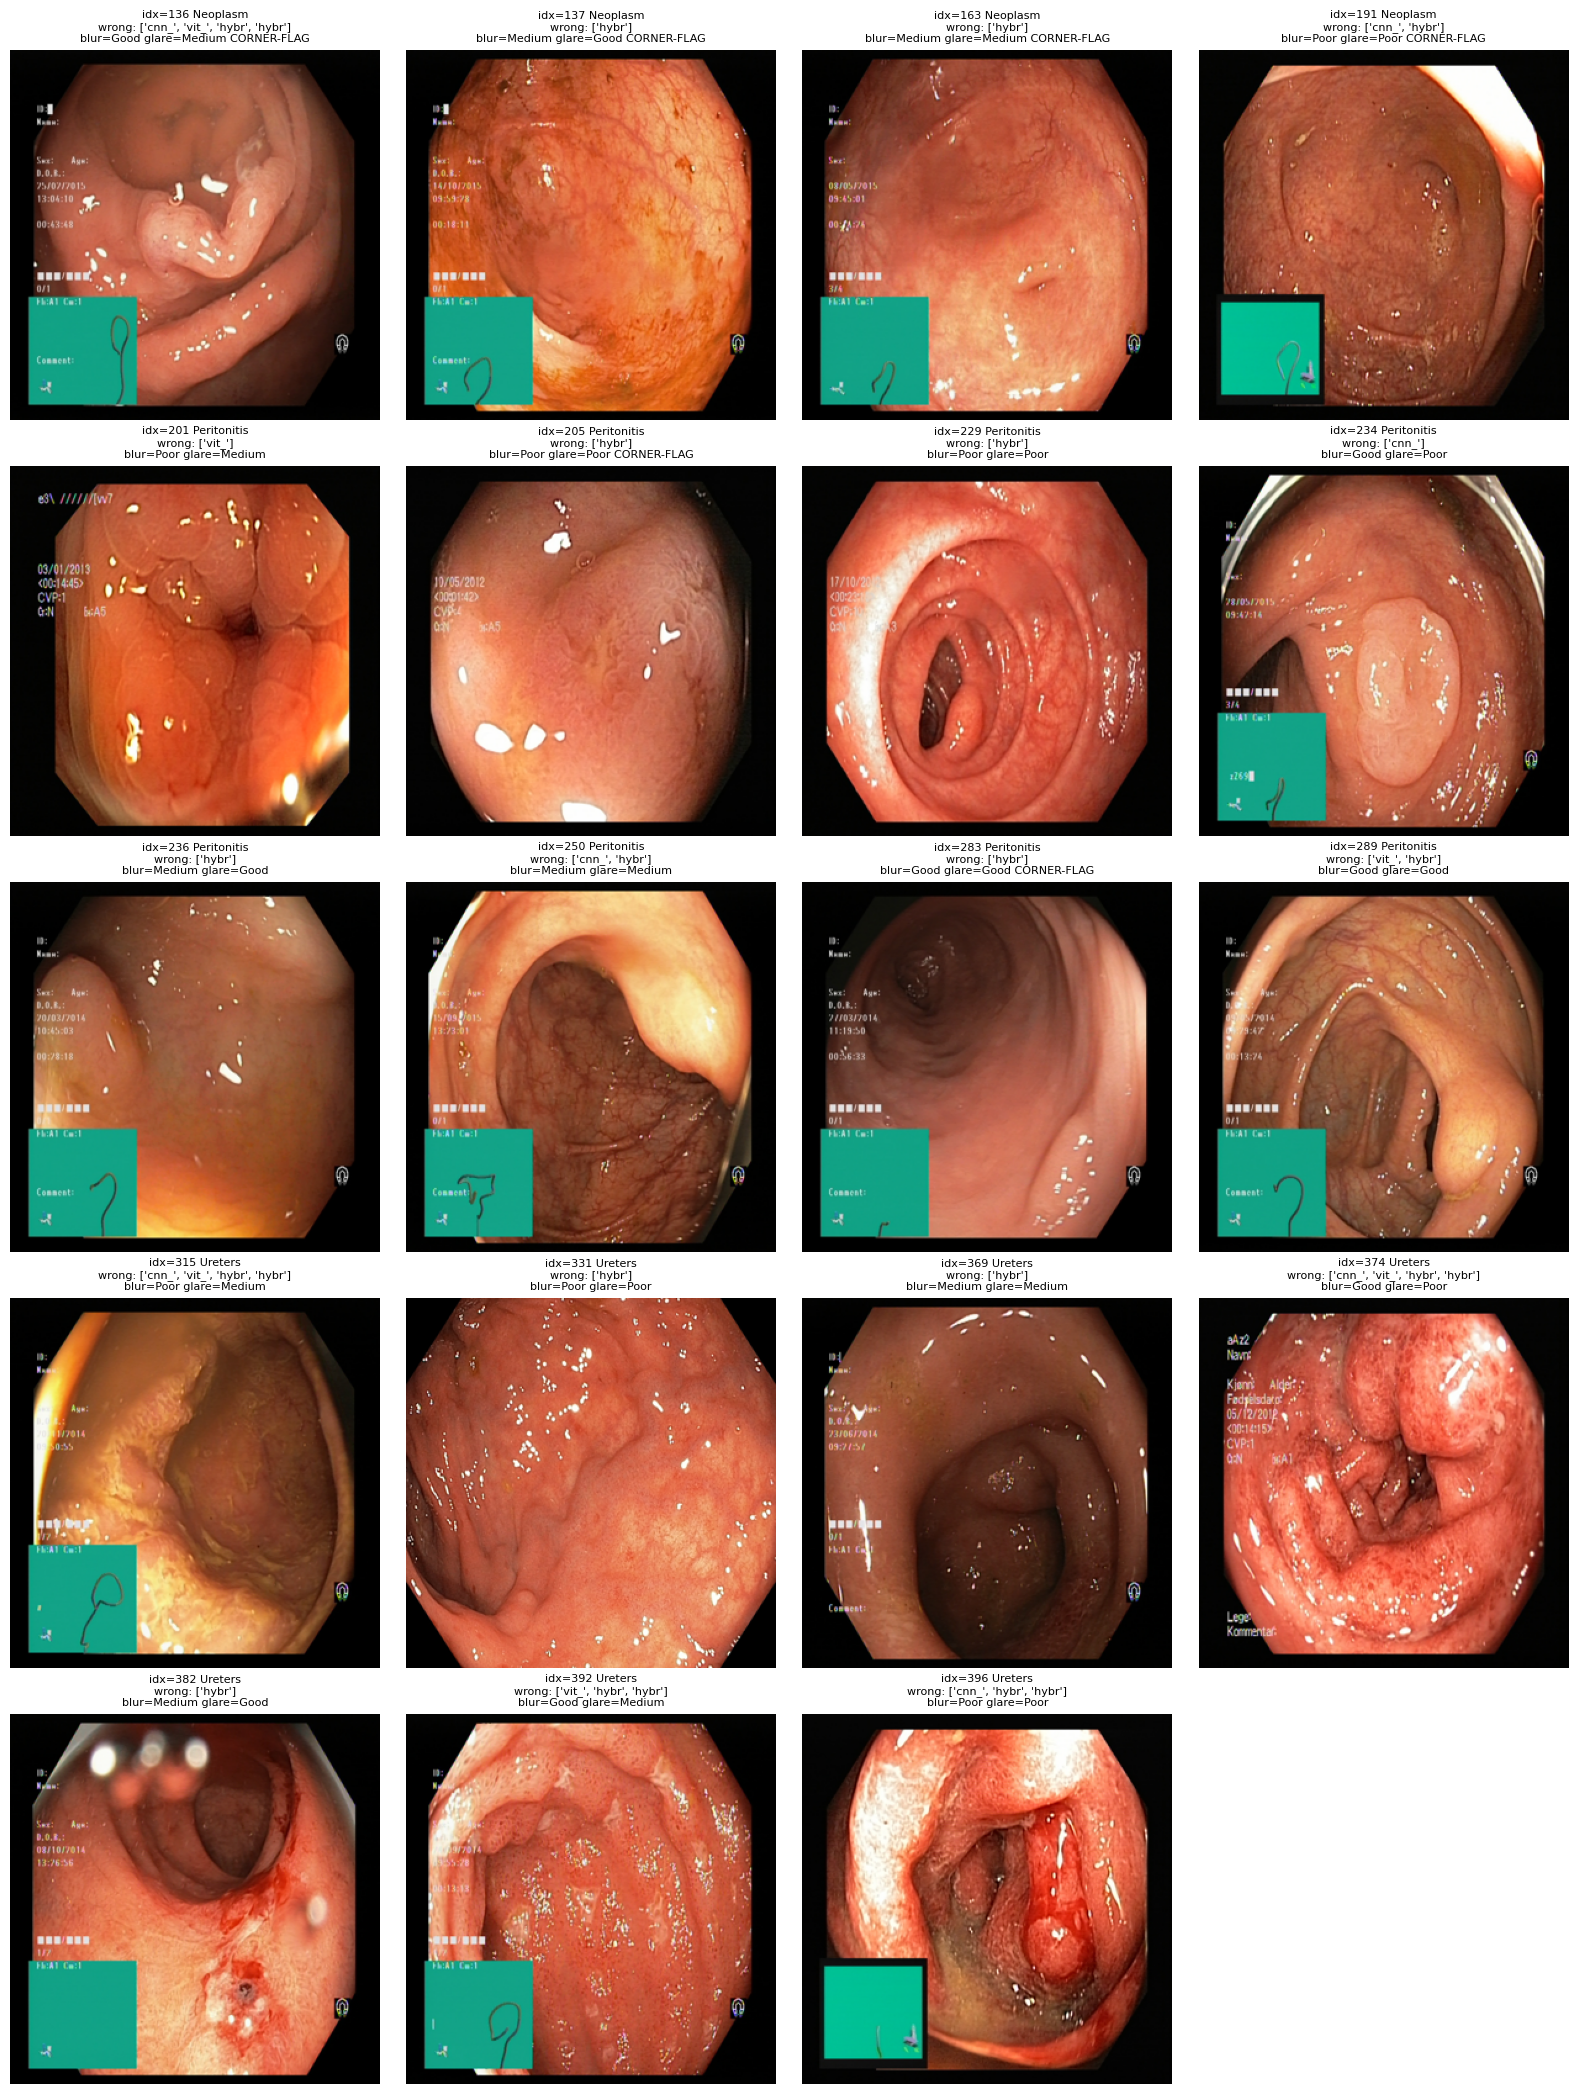

In [23]:
n = len(DISAGREEMENT_INDICES)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4.2 * nrows))
axes = axes.flatten()

for ax, i in zip(axes, DISAGREEMENT_INDICES):
    path, cls = test_entries[i]
    img = Image.open(path).convert("RGB").resize((300, 300))
    ax.imshow(img)
    q = quality_df.loc[quality_df.test_index == i].iloc[0]
    o = overlay_df.loc[overlay_df.test_index == i].iloc[0]
    max_corner_ratio = max(o[c] for c in ratio_cols)
    flag = " CORNER-FLAG" if max_corner_ratio > 1.5 else ""
    wrong_in = [MODEL_FAMILIES[j][:4] for j in range(4) if error_matrix[i, j] == 1]
    ax.set_title(f"idx={i} {cls}\nwrong: {wrong_in}\nblur={q.blur_rating} glare={q.glare_rating}{flag}",
                 fontsize=8)
    ax.axis("off")

for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(analysis_dir, "nb9_contact_sheet.png"), dpi=110, bbox_inches="tight")
plt.show()
plt.close(fig)

## 10. Section D — Cross-model error-overlap summary (brief Section 15, already partly covered by NB6b, restated here in confidence terms)

In [24]:
overlap_rows = []
for i in DISAGREEMENT_INDICES:
    wrong_fams = [MODEL_FAMILIES[j] for j in range(4) if error_matrix[i, j] == 1]
    correct_fams = [f for f in MODEL_FAMILIES if f not in wrong_fams]
    sub = confidence_df[confidence_df.test_index == i]
    conf_on_wrong = sub[sub.model_family.isin(wrong_fams)].top1_prob.mean() if wrong_fams else np.nan
    conf_on_correct = sub[sub.model_family.isin(correct_fams)].top1_prob.mean() if correct_fams else np.nan
    overlap_rows.append({
        "test_index": i, "true_class": CLASS_NAMES[LABELS[i]],
        "n_models_wrong": len(wrong_fams), "wrong_models": ",".join(wrong_fams),
        "mean_confidence_wrong_models": conf_on_wrong,
        "mean_confidence_correct_models": conf_on_correct,
    })
overlap_df = pd.DataFrame(overlap_rows)
print(overlap_df.to_string(index=False, formatters={
    "mean_confidence_wrong_models": "{:.3f}".format,
    "mean_confidence_correct_models": "{:.3f}".format}))

 test_index  true_class  n_models_wrong                                                 wrong_models mean_confidence_wrong_models mean_confidence_correct_models
        136    Neoplasm               4 cnn_only_v2,vit_only_v2,hybrid_concat_v2,hybrid_crossattn_v2                        0.986                            NaN
        137    Neoplasm               1                                             hybrid_concat_v2                        0.979                          0.923
        163    Neoplasm               1                                             hybrid_concat_v2                        0.975                          0.842
        191    Neoplasm               2                                 cnn_only_v2,hybrid_concat_v2                        0.866                          0.864
        201 Peritonitis               1                                                  vit_only_v2                        0.973                          0.926
        205 Peritonitis           

## 11. Section E — Auto-generated hypothesis report (brief Section 36/40 format)

In [25]:
print("="*72)
print("AUTOMATED DIAGNOSTIC SUMMARY -- NB9")
print("="*72)

n_total = len(DISAGREEMENT_INDICES)

# --- Confidence pattern ---
high_conf_err = (confidence_df.confidence_bucket == "high_confidence_error").sum()
low_conf_err = (confidence_df.confidence_bucket == "low_confidence_error").sum()
print(f"\nOBSERVATION: Across {n_total} disagreement images x 4 models, "
      f"{high_conf_err} model-image pairs are high-confidence errors (top1 > 0.75) "
      f"vs {low_conf_err} low-confidence errors.")
if high_conf_err > low_conf_err:
    print("HYPOTHESIS: Errors are dominated by confidently-wrong predictions, not borderline "
          "uncertainty -- suggests a systematic feature/shortcut issue rather than images sitting "
          "exactly on a decision boundary.")
else:
    print("HYPOTHESIS: Errors are dominated by genuine model uncertainty (close top-1/top-2), "
          "consistent with intrinsically ambiguous or borderline images rather than a systematic bug.")

# --- Quality pattern ---
poor_blur = (quality_df.blur_rating == "Poor").sum()
poor_glare = (quality_df.glare_rating == "Poor").sum()
print(f"\nOBSERVATION: {poor_blur}/{n_total} disagreement images fall in the bottom blur tercile; "
      f"{poor_glare}/{n_total} fall in the top glare tercile (dataset-relative).")
if poor_blur >= n_total * 0.4 or poor_glare >= n_total * 0.4:
    print("HYPOTHESIS: A meaningful share of errors coincide with poor image quality (blur/glare).")
    print("PROPOSED EXPERIMENT: targeted augmentation matching the flagged quality issue "
          "(e.g. mild blur augmentation, exposure/brightness jitter) -- NOT a new architecture.")
    print("EXPECTED OUTCOME: marginal recall improvement on the affected class(es), tested across 3-5 seeds.")
else:
    print("HYPOTHESIS: Image quality is NOT a dominant driver of these errors -- most disagreement "
          "images are dataset-typical quality. Do not prioritize quality-targeted augmentation.")

# --- Overlay-attention pattern ---
corner_flagged = (overlay_df[ratio_cols].max(axis=1) > 1.5).sum()
print(f"\nOBSERVATION: {corner_flagged}/{n_total} disagreement images show at least one model's "
      f"attention (Grad-CAM or cross-attn) concentrated >1.5x above uniform in a corner region.")
if corner_flagged >= max(3, n_total * 0.25):
    print("HYPOTHESIS: Burned-in overlay graphics in the corners of some frames may be drawing "
          "model attention away from tissue on a non-trivial subset of images.")
    print("PROPOSED EXPERIMENT: crop/mask the fixed overlay region (if its position is consistent "
          "across the dataset) and re-evaluate the flagged images only -- cheap, no retraining needed "
          "if done as a masked-inference check first.")
    print("EXPECTED OUTCOME: if predictions on flagged images change substantially under masking, "
          "this is a real robustness issue worth reporting. If predictions are stable, drop it.")
else:
    print("HYPOTHESIS: Corner/overlay attention is NOT systematic across the disagreement set -- "
          "the single image noticed manually earlier appears to be an isolated case, not a pattern.")
    print("PROPOSED EXPERIMENT: none needed -- do not report this as a limitation without more evidence.")

print(f"\nOBSERVATION: {n_total}/400 test images produce any disagreement (per NB6b) -- the residual "
      f"error is small and concentrated, consistent with a near-ceiling dataset rather than an "
      f"architecture gap (all 4 architectures were already shown statistically tied in NB6).")
print("\nBOTTOM LINE: nothing in this automated pass provides strong, systematic evidence for a fixable "
      "architecture or preprocessing problem. Any single flagged item above should be treated as a "
      "narrow, explicit hypothesis to test cheaply (per the summary printed above) -- not as grounds "
      "for a new architecture or a larger experiment campaign.")

AUTOMATED DIAGNOSTIC SUMMARY -- NB9

OBSERVATION: Across 19 disagreement images x 4 models, 20 model-image pairs are high-confidence errors (top1 > 0.75) vs 14 low-confidence errors.
HYPOTHESIS: Errors are dominated by confidently-wrong predictions, not borderline uncertainty -- suggests a systematic feature/shortcut issue rather than images sitting exactly on a decision boundary.

OBSERVATION: 7/19 disagreement images fall in the bottom blur tercile; 7/19 fall in the top glare tercile (dataset-relative).
HYPOTHESIS: Image quality is NOT a dominant driver of these errors -- most disagreement images are dataset-typical quality. Do not prioritize quality-targeted augmentation.

OBSERVATION: 6/19 disagreement images show at least one model's attention (Grad-CAM or cross-attn) concentrated >1.5x above uniform in a corner region.
HYPOTHESIS: Burned-in overlay graphics in the corners of some frames may be drawing model attention away from tissue on a non-trivial subset of images.
PROPOSED EX

## 12. Save outputs

In [26]:
confidence_df.to_csv(os.path.join(analysis_dir, "nb9_confidence_stratification.csv"), index=False)
quality_df.to_csv(os.path.join(analysis_dir, "nb9_image_quality.csv"), index=False)
overlay_df.to_csv(os.path.join(analysis_dir, "nb9_overlay_attention.csv"), index=False)
overlap_df.to_csv(os.path.join(analysis_dir, "nb9_cross_model_overlap.csv"), index=False)

print(f"Saved to {analysis_dir}:")
print("  nb9_confidence_stratification.csv  -- per (image, model) confidence/entropy/bucket")
print("  nb9_image_quality.csv              -- blur/brightness/contrast/glare, dataset-relative rating")
print("  nb9_overlay_attention.csv          -- corner-mass ratio per model per image")
print("  nb9_cross_model_overlap.csv        -- which models got which images wrong, at what confidence")
print("  nb9_contact_sheet.png              -- all 19 images with flags")
print()


Saved to /content/drive/MyDrive/gastronet_experiments/analysis:
  nb9_confidence_stratification.csv  -- per (image, model) confidence/entropy/bucket
  nb9_image_quality.csv              -- blur/brightness/contrast/glare, dataset-relative rating
  nb9_overlay_attention.csv          -- corner-mass ratio per model per image
  nb9_cross_model_overlap.csv        -- which models got which images wrong, at what confidence
  nb9_contact_sheet.png              -- all 19 images with flags

